In [49]:
%load_ext autoreload
%autoreload 2

import torch

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
from tqdm.notebook import tqdm_notebook as tqdm
import time
total_epochs = 100
epoch_bar = tqdm(range(total_epochs), desc="Epochs")

for i in epoch_bar:
    time.sleep(0.01)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

### Preprocess Data

In [51]:
from preprocess_data import preprocess_data
from pathlib import Path

print("Preprocessing training data...")
preprocess_data(data_dir=Path("Results/"), split="train", noise_scale=0.0003, recalc_velocities=True)

print()
print("Preprocessing test data...")
preprocess_data(data_dir=Path("Results/"), split="val", recalc_velocities=True)

Preprocessing training data...
Processing trajectory: 0
Length of trajectory 0: 49
Processing trajectory: 1
Length of trajectory 1: 49
Processing trajectory: 2
Length of trajectory 2: 49
Processing trajectory: 3
Length of trajectory 3: 49
Processing trajectory: 4
Length of trajectory 4: 49
Processing trajectory: 5
Length of trajectory 5: 49
Processing trajectory: 6
Length of trajectory 6: 49
Processing trajectory: 7
Length of trajectory 7: 49
Processing trajectory: 8
Length of trajectory 8: 49
Processing trajectory: 9
Length of trajectory 9: 49
Processing trajectory: 10
Length of trajectory 10: 49
Processing trajectory: 11
Length of trajectory 11: 49
Processing trajectory: 12
Length of trajectory 12: 49
Processing trajectory: 13
Length of trajectory 13: 49
Processing trajectory: 14
Length of trajectory 14: 49
Processing trajectory: 15
Length of trajectory 15: 49
Processing trajectory: 16
Length of trajectory 16: 49
Processing trajectory: 17
Length of trajectory 17: 49
Processing trajec

### Load Dataset

In [52]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

train_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/train")
test_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/val")

batch_size = 16
num_workers = 4
train_dataloader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers
)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Found 54 sample files
Loaded the dataset with 2646 samples
Found 1 sample files
Loaded the dataset with 49 samples


### Initialize Model

In [53]:
from models.vinay_mgn import MeshGraphNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

node_channels = 13
edge_channels = 8
num_messages = 8
latent_dim = 128

model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
_ = model.to(device)

### Initialize Trainer

In [68]:
from trainer import Trainer

lr = 5e-5
loss_type = "mse"

optimizer = torch.optim.Adam(model.parameters(), lr=lr)
trainer = Trainer(model, optimizer, device, loss_type=loss_type)
torch.cuda.empty_cache()

### Train Loop

In [69]:
from tqdm.notebook import tqdm_notebook as tqdm
from preprocess_data import Stats
import json

print("Loading stats...")
with open("Results/train/stats/stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])
dt = 0.08

total_epochs = 50

epoch_bar = tqdm(range(total_epochs), desc="Epochs")
for epoch in epoch_bar:
    for batch in tqdm(train_dataloader, desc="Batches", leave=False):
        # print("hey")
        batch.to(device)
        trainer.train(batch)

    trainer.test(
        test_loader=test_dataloader,
        node_stats=node_stats,
        edge_stats=edge_stats,
        target_stats=target_stats,
        dt=dt,
    )
    trainer.epoch_end()
    trainer.save_model(epoch=epoch)
    epoch_bar.set_postfix(
        {
            "last_loss": f"{trainer.loss:.6f}, gen_loss: {trainer.gen_test_history[-1]:.6f}"
        }
    )


Loading stats...


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

Batches:   0%|          | 0/166 [00:00<?, ?it/s]

### Show Training Progress

[   0  166  332  498  664  830  996 1162 1328 1494 1660 1826 1992 2158
 2324 2490 2656 2822 2988 3154 3320 3486 3652 3818 3984 4150 4316 4482
 4648 4814 4980 5146 5312 5478 5644 5810 5976 6142 6308 6474 6640 6806
 6972 7138 7304 7470 7636 7802 7968 8134]


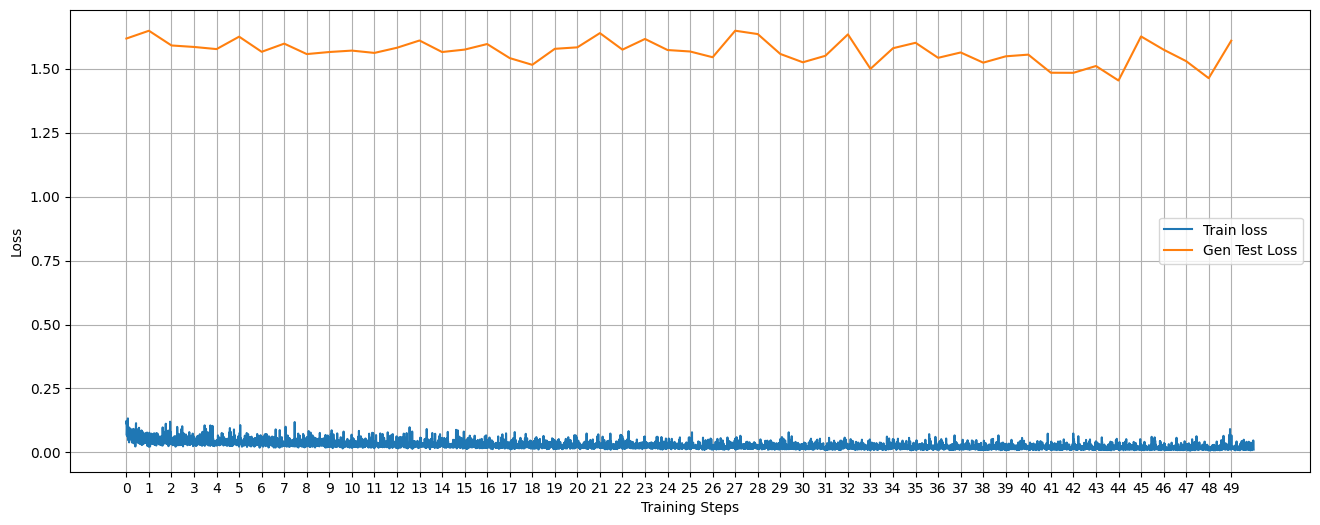

In [70]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss(trainer: Trainer):
    len(train_dataloader)
    epochs_indices = np.arange(
        0, total_epochs * len(train_dataloader), len(train_dataloader)
    )
    print(epochs_indices)
    plt.figure(figsize=(16, 6))
    plt.plot(trainer.train_history, label="Train loss")
    plt.plot(epochs_indices, trainer.gen_test_history, label="Gen Test Loss")
    plt.legend()
    plt.xlabel("Training Steps")
    plt.ylabel("Loss")
    plt.xticks(epochs_indices, [str(i) for i in range(total_epochs)])
    plt.grid()
    plt.show()
plot_loss(trainer)

# PIPELINE

In [ ]:
preprocess_dataset()
train_dataloader, test_dataloader = get_dataloaders()
model = get_model()
trainer = get_trainer(model)
run_train(trainer, train_dataloader, test_dataloader)
plot_loss(trainer)
print("Training complete.")

### Show animation

In [71]:
from rollout_utils import do_rollout

model = trainer.model.eval()
no_rollout = False
error_x, error_v, error_stress, true_rollout, pred_rollout = do_rollout(
    model=model,
    test_loader=test_dataloader,
    device=trainer.device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
    skip_first=0,
    skip_after=30,
    dont_rollout=no_rollout,
)

In [72]:
error_x

[tensor(0.0001),
 tensor(0.0004),
 tensor(0.0008),
 tensor(0.0015),
 tensor(0.0025),
 tensor(0.0037),
 tensor(0.0051),
 tensor(0.0067),
 tensor(0.0082),
 tensor(0.0100),
 tensor(0.0115),
 tensor(0.0118),
 tensor(0.0098),
 tensor(0.0061),
 tensor(0.0034),
 tensor(0.0067),
 tensor(0.0108),
 tensor(0.0127),
 tensor(0.0117),
 tensor(0.0083),
 tensor(0.0048),
 tensor(0.0076),
 tensor(0.0127),
 tensor(0.0161),
 tensor(0.0164),
 tensor(0.0134),
 tensor(0.0087),
 tensor(0.0076),
 tensor(0.0120),
 tensor(0.0164),
 tensor(0.0174)]

In [73]:
from make_gif import make_beam_comparison_gif


make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif="beam_comparison.gif",
    fps=4,
)

Rendering frame 0/30


/scratch/imos-students/ksteiner/BeamElastoDynamics/make_gif.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


Rendering frame 1/30
Rendering frame 2/30
Rendering frame 3/30
Rendering frame 4/30
Rendering frame 5/30
Rendering frame 6/30
Rendering frame 7/30
Rendering frame 8/30
Rendering frame 9/30
Rendering frame 10/30
Rendering frame 11/30
Rendering frame 12/30
Rendering frame 13/30
Rendering frame 14/30
Rendering frame 15/30
Rendering frame 16/30
Rendering frame 17/30
Rendering frame 18/30
Rendering frame 19/30
Rendering frame 20/30
Rendering frame 21/30
Rendering frame 22/30
Rendering frame 23/30
Rendering frame 24/30
Rendering frame 25/30
Rendering frame 26/30
Rendering frame 27/30
Rendering frame 28/30
Rendering frame 29/30
Rendering frame 30/30
GIF saved => beam_comparison.gif
Done.


In [74]:
# from IPython.display import Image

# Image(filename="beam_comparison.gif")